In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [81]:
df = pd.read_csv("smart factory machinery data set.csv")

# Task 1: Simple Linear Regression  

● The Goal: Establish the baseline of predictive modeling. 

● The Action: Start with a clean subset of the factory data. Train a simple linear regression model to predict the machine's internal Temperature using just a single continuous variable, such as RPM. 

● The Research: Have the student plot the line of best fit and calculate the Mean Squared Error (MSE) to establish a baseline performance. 

In [82]:
X = df[['Rotational speed [rpm]']]
y = df['Process temperature [K]']

In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [84]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [85]:
y_pred = model.predict(X_test)

In [86]:
mse_simple = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse_simple)

Mean Squared Error: 2.1691240317336407


In [87]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 0.00018221851258225778
Intercept: 309.72569391219616


In [88]:
sorted_index = X_test.squeeze().argsort()

X_test_sorted = X_test.squeeze().iloc[sorted_index]
y_pred_sorted = y_pred[sorted_index]

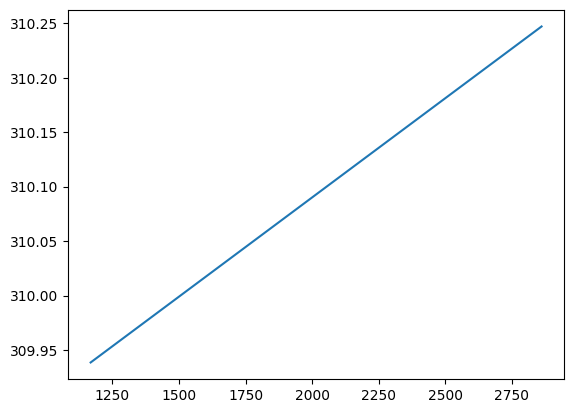

In [89]:
plt.plot(X_test_sorted, y_pred_sorted)

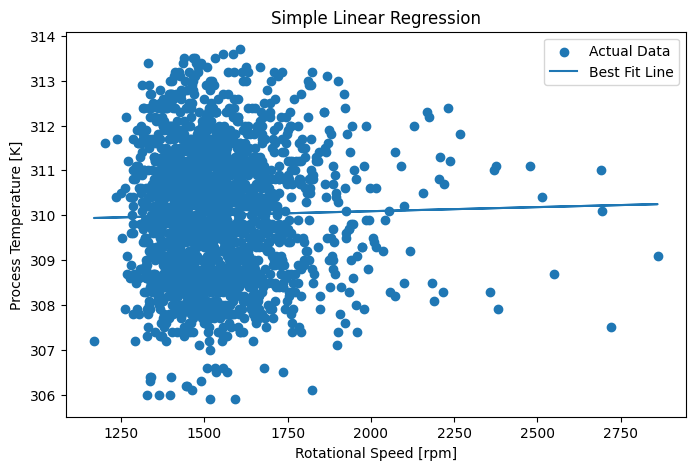

In [90]:
plt.figure(figsize=(8,5))

plt.scatter(X_test, y_test, label="Actual Data")
plt.plot(X_test, y_pred, label="Best Fit Line")

plt.xlabel("Rotational Speed [rpm]")
plt.ylabel("Process Temperature [K]")

plt.title("Simple Linear Regression")

plt.legend()
plt.show()

# Task 2: Multivariable Regression

● The Goal: Introduce complexity and multi-dimensional data. 

● The Action: Upgrade the model to predict Temperature using multiple continuous variables simultaneously (e.g., RPM, Vibration, and Pressure). 

● The Research: Compare the MSE of this new model against the simple model from Task 1. The student must document why adding more relevant features usually (but not always) reduces the error rate. 

In [91]:
X_multi = df[
    [
        'Air temperature [K]',
        'Rotational speed [rpm]',
        'Torque [Nm]',
        'Tool wear [min]'
    ]
]

y_multi = df['Process temperature [K]']

In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=42
)

In [93]:
multi_model = LinearRegression()

multi_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [94]:
y_pred_multi = multi_model.predict(X_test)

In [95]:
mse_multi = mean_squared_error(y_test, y_pred_multi)

print("Multivariable Regression MSE:", mse_multi)

Multivariable Regression MSE: 0.529870876536166


In [96]:
print("Simple Regression MSE:", mse_simple)
print("Multiple Regression MSE:", mse_multi)

Simple Regression MSE: 2.1691240317336407
Multiple Regression MSE: 0.529870876536166


In [97]:
coefficients = pd.DataFrame({
    'Feature': X_multi.columns,
    'Coefficient': multi_model.coef_
})

print(coefficients)

                  Feature  Coefficient
0     Air temperature [K]     0.651688
1  Rotational speed [rpm]    -0.000099
2             Torque [Nm]    -0.002450
3         Tool wear [min]    -0.000066


# Task 3: Save Model  

Smart Factory Machinery Predictor  

● The Goal: Bridge the gap between a local script and a deployable asset. 

● The Action: Take the best-performing multivariable model from the morning session and serialize it to the hard drive using libraries like pickle or joblib. 

● The Research: Write a short script in a separate file to load this saved model and predict the temperature for a mock "new" machine reading. This proves the model is detached from the training environment. 

In [98]:
import joblib

In [99]:
joblib.dump(multi_model, "temperature_predictor.pkl")

['temperature_predictor.pkl']

In [100]:
print("Model saved successfully!")

Model saved successfully!


In [101]:
import joblib

joblib.dump(multi_model, "temperature_predictor.pkl")

print("Model saved successfully!")

Model saved successfully!


In [102]:
import joblib
import pandas as pd

# Load saved model
model = joblib.load("temperature_predictor.pkl")

# Create mock new machine data
new_machine = pd.DataFrame({
    'Air temperature [K]': [300.5],
    'Rotational speed [rpm]': [1500],
    'Torque [Nm]': [45.2],
    'Tool wear [min]': [25]
})

# Predict temperature
prediction = model.predict(new_machine)

print("Predicted Process Temperature:", prediction[0])

Predicted Process Temperature: 310.3220611830611


# Task 4: One-Hot Encoding 

● The Goal: Learn to handle real-world, non-numeric factory data. 

● The Action: Introduce a categorical column to the dataset (e.g., "Machine Mode: Eco, Standard, High-Speed"). Use encoding techniques to convert these text labels into binary columns ($1$s and $0$s) so a machine learning algorithm can process them. 

● The Research: Explain the "Dummy Variable Trap" and why one column is often dropped after encoding. 

In [103]:
from sklearn.preprocessing import OneHotEncoder

In [104]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Select categorical column
type_data = df[['Type']]

# Create encoder
encoder = OneHotEncoder(drop='first', sparse_output=False)

# Transform data
encoded = encoder.fit_transform(type_data)

# Convert to DataFrame
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['Type'])
)

print(encoded_df.head())

   Type_L  Type_M
0     0.0     1.0
1     1.0     0.0
2     1.0     0.0
3     1.0     0.0
4     1.0     0.0


In [105]:
print(df['Type'].unique())
encoded_df = pd.get_dummies(
    df,
    columns=['Type'],
    drop_first=True
)

<StringArray>
['M', 'L', 'H']
Length: 3, dtype: str


In [106]:
print(encoded_df.head())

   UDI Product ID  Air temperature [K]  Process temperature [K]  \
0    1     M14860                298.1                    308.6   
1    2     L47181                298.2                    308.7   
2    3     L47182                298.1                    308.5   
3    4     L47183                298.2                    308.6   
4    5     L47184                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  Type_L  Type_M  
0    0    0    0    0   False    True  
1    0    0    0    0    True 

# Task 5: Train-Test Split  

● The Goal: Prevent the model from merely memorizing the data (overfitting). 

● The Action: Take the newly encoded, complex dataset and strictly divide it (e.g., 80% for training, 20% for testing) before feeding it to any algorithm. 

● The Research: Train a new multivariable model on the 80% split and test it on the 20%. The student must document why evaluating a model on the exact same data it was trained on is a critical failure in data science. 

In [107]:
import pandas as pd

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [108]:
type_data = df[['Type']]

# Create encoder
encoder = OneHotEncoder(
    drop='first',          # Avoid Dummy Variable Trap
    sparse_output=False
)

# Encode categorical data
encoded_array = encoder.fit_transform(type_data)

# Convert encoded data to DataFrame
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(['Type'])
)

In [109]:
X['Air temperature [K]'] = df['Air temperature [K]']
X['Rotational speed [rpm]'] = df['Rotational speed [rpm]']
X['Torque [Nm]'] = df['Torque [Nm]']
X['Tool wear [min]'] = df['Tool wear [min]']

In [110]:
y = df['Process temperature [K]']


In [111]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [112]:
split_model = LinearRegression()

split_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [113]:
y_pred = split_model.predict(X_test)


In [114]:
mse_split = mean_squared_error(y_test, y_pred)

print("Test Set MSE:", mse_split)

Test Set MSE: 0.5298708765361672


# Task 6: Logistic Regression  

● The Goal: Shift from predicting a continuous number to predicting a distinct category. 

● The Action: Using the properly split and encoded dataset, train a Logistic Regression classifier to predict a binary outcome: 1 if a manufactured part will be Defective, and 0 if it will be Good. 

● The Research: Generate a Confusion Matrix for the test set predictions. The student must analyze the real-world factory cost of a False Positive (throwing away a good part) versus a False Negative (shipping a broken part to a customer). 

In [115]:
import pandas as pd

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [116]:
type_data = df[['Type']]

# Create encoder
encoder = OneHotEncoder(
    drop='first',
    sparse_output=False
)

# Encode data
encoded_array = encoder.fit_transform(type_data)

# Convert encoded array to dataframe
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(['Type'])
)


In [117]:
X = encoded_df.copy()

# Add numerical features
X['Air temperature [K]'] = df['Air temperature [K]']
X['Process temperature [K]'] = df['Process temperature [K]']
X['Rotational speed [rpm]'] = df['Rotational speed [rpm]']
X['Torque [Nm]'] = df['Torque [Nm]']
X['Tool wear [min]'] = df['Tool wear [min]']

In [120]:
y = df['Machine failure']

In [123]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [124]:

log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [125]:
y_pred = log_model.predict(X_test)


In [126]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)



Accuracy: 0.974


In [127]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)



Confusion Matrix:
[[1930    9]
 [  43   18]]


In [128]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1939
           1       0.67      0.30      0.41        61

    accuracy                           0.97      2000
   macro avg       0.82      0.65      0.70      2000
weighted avg       0.97      0.97      0.97      2000

